In [ ]:
import glob
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

workspace = Path.home() / "bicycle-architecture-compiler" /"saved_metrics"

# 1. Discover and load metrics CSV files (handles exact name or wildcard sweep)
target_file = workspace / "metrics n4,8,16,32 1e-3 no gidney.csv"
if target_file.exists():
    csv_files = [str(target_file)]
else:
    csv_files = sorted(glob.glob(str(workspace / "metrics*.csv")))

if not csv_files:
    raise FileNotFoundError(f"No metrics CSV files found in {workspace}")

df_list = [pd.read_csv(f) for f in csv_files]
master_df = pd.concat(df_list, ignore_index=True).drop_duplicates(subset=["adder", "partition"])

# 2. Extract Adder Family Name and Bit-Width (n)
def parse_adder(name):
    m = re.match(r"([a-z_]+)_n(\d+)", str(name))
    if m:
        return m.group(1), int(m.group(2))
    return str(name), 4

master_df[["family", "n_bits"]] = master_df["adder"].apply(lambda x: pd.Series(parse_adder(x)))
master_df["clean_adder"] = master_df["family"].str.replace("_", " ").str.title()

# 3. Metrics to compute deltas for (metric_col, diff_name, pct_name)
delta_metric_targets = [
    ("measurement_depth", "depth_diff", "depth_pct"),
    ("end_time", "time_diff", "time_pct"),
    ("im_gates", "im_gates_diff", "im_gates_pct"),
    ("im_hops", "im_hops_diff", "im_hops_pct"),
    ("total_im_hops", "total_im_hops_diff", "total_im_hops_pct"),
    ("total_im_events", "total_im_events_diff", "total_im_events_pct"),
    ("factory_delivery_hops", "factory_hops_diff", "factory_hops_pct"),
    ("measurements", "measurements_diff", "measurements_pct"),
    ("automorphisms", "automorphisms_diff", "automorphisms_pct"),
]

# 4. Compute deltas relative to unpartitioned 'original' baseline
rows = []
for (fam, n), group in master_df.groupby(["family", "n_bits"]):
    orig_rows = group[group["partition"] == "original"]
    if orig_rows.empty:
        continue
    orig = orig_rows.iloc[0]

    for _, row in group.iterrows():
        d = row.to_dict()

        # Dynamic module count based on allocated slots (supports 11 or 12 capacity)
        cap = 11 if ("allocated_qubits" in row and row["allocated_qubits"] % 11 == 0) else 12
        d["modules"] = row["allocated_qubits"] // cap

        # Normalized efficiency rates
        if "pbc_steps" in row and pd.notna(row["pbc_steps"]) and row["pbc_steps"] > 0:
            d["cycles_per_pbc_step"] = row["end_time"] / row["pbc_steps"]

        # Compute absolute and percentage deltas across all available metrics
        for col, diff_col, pct_col in delta_metric_targets:
            if col in row and col in orig and pd.notna(row[col]) and pd.notna(orig[col]):
                val = row[col]
                orig_val = orig[col]
                d[diff_col] = val - orig_val
                d[pct_col] = ((val - orig_val) / orig_val) * 100.0 if orig_val != 0 else 0.0

        rows.append(d)

df_all = pd.DataFrame(rows)

# Clean display of loaded data
bit_widths = sorted(df_all["n_bits"].unique())
partitions = sorted(df_all["partition"].unique())
print(f"✓ Successfully built df_all with {len(df_all)} configurations.")
print(f"  • Bit-widths: {bit_widths}")
print(f"  • Partitions: {partitions}")
print(f"  • Delta metrics available: {[c for c in df_all.columns if c.endswith('_diff')]}")

✓ Successfully built df_all with 100 configurations.
  • Bit-widths: [np.int64(4), np.int64(8), np.int64(16), np.int64(32)]
  • Partitions: ['clustering', 'kahypar', 'metis', 'original', 'weighted_degree']
  • Delta metrics available: ['depth_diff', 'time_diff', 'im_gates_diff', 'im_hops_diff', 'measurements_diff', 'automorphisms_diff']


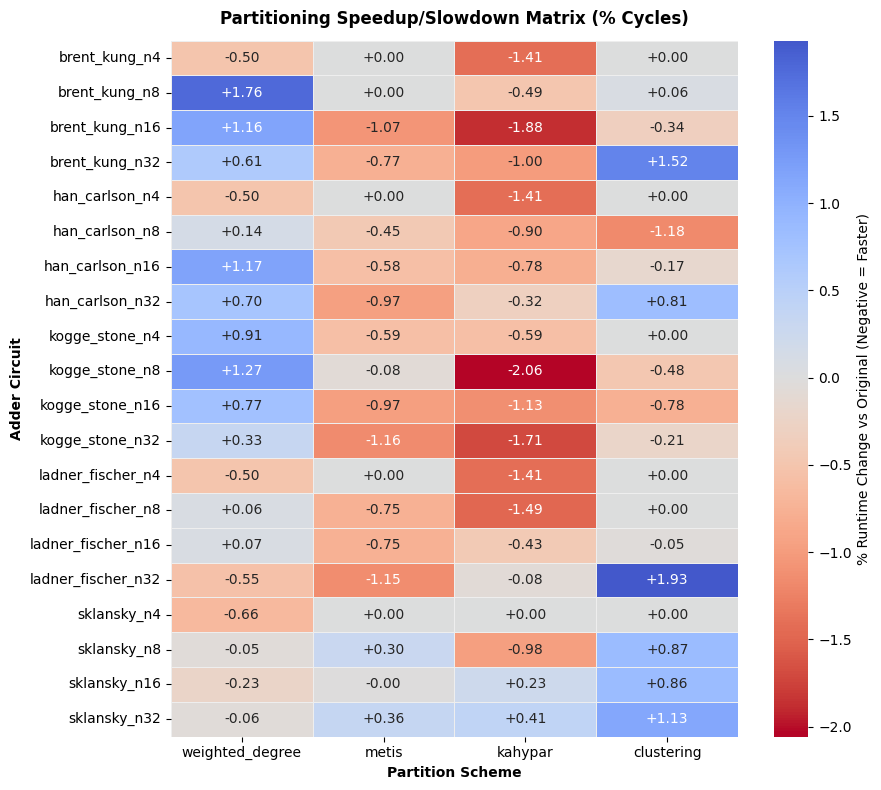

In [25]:
# Filter out baseline
heatmap_df = df_all[df_all["partition"] != "original"].copy()

# Natural sort by family and bit-width
heatmap_df["sort_key"] = heatmap_df["family"] + "_" + heatmap_df["n_bits"].astype(str).str.zfill(2)
sorted_adders = heatmap_df.sort_values(["family", "n_bits"])["adder"].unique()

pivot_time_pct = heatmap_df.pivot_table(
    index="adder", columns="partition", values="time_pct"
).reindex(sorted_adders)[["weighted_degree", "metis", "kahypar", "clustering"]]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    pivot_time_pct,
    annot=True,
    fmt="+.2f",
    cmap="coolwarm_r",
    center=0,
    cbar_kws={"label": "% Runtime Change vs Original (Negative = Faster)"},
    linewidths=0.6,
    linecolor="#eeeeee",
    ax=ax
)
ax.set_title("Partitioning Speedup/Slowdown Matrix (% Cycles)", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Partition Scheme", fontweight="bold")
ax.set_ylabel("Adder Circuit", fontweight="bold")
plt.tight_layout()
plt.show()

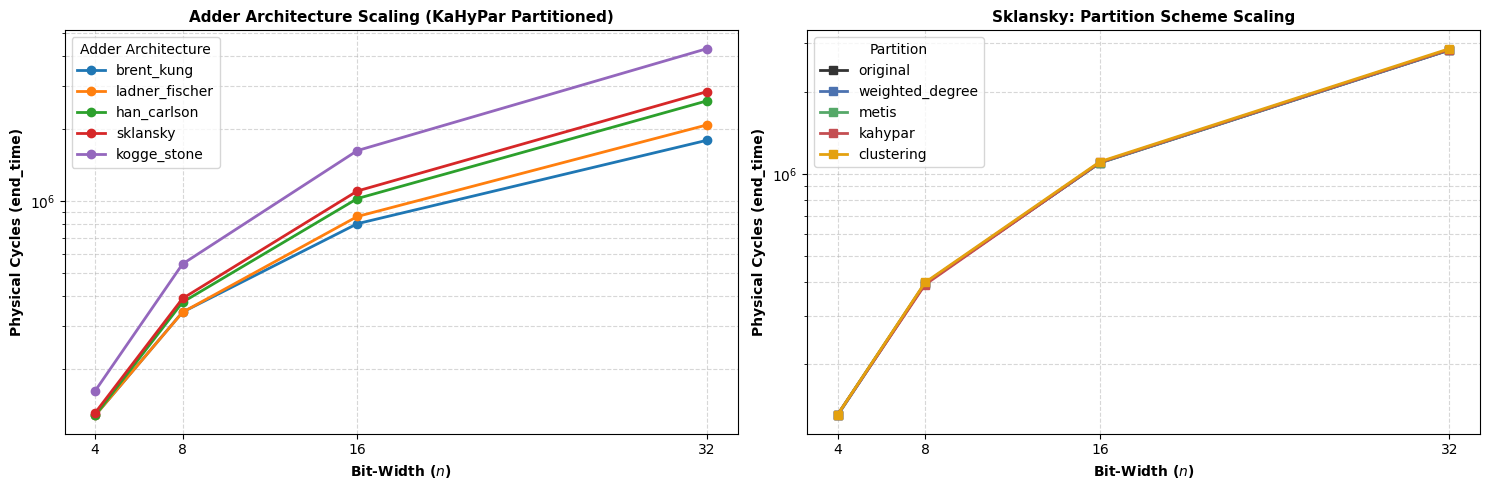

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A: Adder Family Scaling under KaHyPar
family_order = ["brent_kung", "ladner_fischer", "han_carlson", "sklansky", "kogge_stone"]
palette_fam = sns.color_palette("tab10", len(family_order))

for i, fam in enumerate(family_order):
    sub = df_all[(df_all["family"] == fam) & (df_all["partition"] == "kahypar")].sort_values("n_bits")
    axes[0].plot(sub["n_bits"], sub["end_time"], marker="o", linewidth=2, label=fam, color=palette_fam[i])

axes[0].set_title("Adder Architecture Scaling (KaHyPar Partitioned)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Bit-Width ($n$)", fontweight="bold")
axes[0].set_ylabel("Physical Cycles (end_time)", fontweight="bold")
axes[0].set_yscale("log")
axes[0].set_xticks([4, 8, 16, 32])
axes[0].grid(True, which="both", linestyle="--", alpha=0.5)
axes[0].legend(title="Adder Architecture")

# Panel B: Partitioning Scheme Scaling on Kogge-Stone
ks_data = df_all[df_all["family"] == "sklansky"].sort_values(["partition", "n_bits"])
part_palette = {"original": "#333333", "weighted_degree": "#4C72B0", "metis": "#55A868", "kahypar": "#C44E52", "clustering": "#E4A10F"}

for part in ["original", "weighted_degree", "metis", "kahypar", "clustering"]:
    sub = ks_data[ks_data["partition"] == part]
    axes[1].plot(sub["n_bits"], sub["end_time"], marker="s", linewidth=2, label=part, color=part_palette[part])

axes[1].set_title("Sklansky: Partition Scheme Scaling", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Bit-Width ($n$)", fontweight="bold")
axes[1].set_ylabel("Physical Cycles (end_time)", fontweight="bold")
axes[1].set_yscale("log")
axes[1].set_xticks([4, 8, 16, 32])
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)
axes[1].legend(title="Partition")

plt.tight_layout()
plt.show()

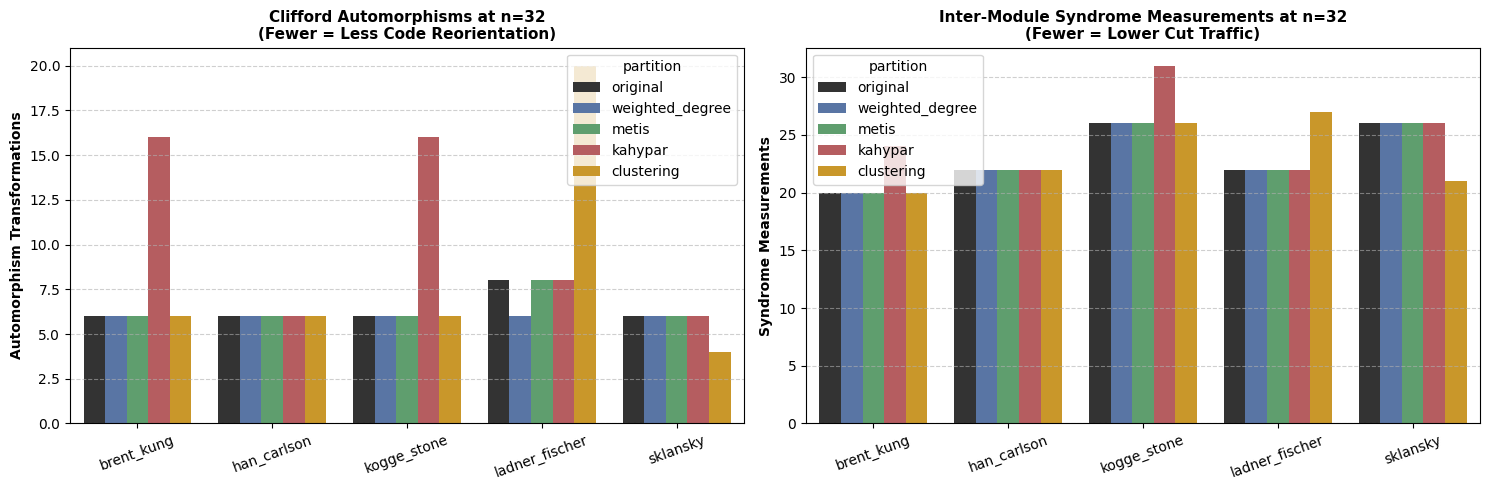

In [27]:
target_n = 32  # Choose bit-width to inspect (8, 16, or 32)
df_slice = df_all[df_all["n_bits"] == target_n].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
part_palette = {"original": "#333333", "weighted_degree": "#4C72B0", "metis": "#55A868", "kahypar": "#C44E52", "clustering": "#E4A10F"}

# 1. Clifford Automorphisms
sns.barplot(
    data=df_slice,
    x="family",
    y="automorphisms",
    hue="partition",
    palette=part_palette,
    ax=axes[0]
)
axes[0].set_title(f"Clifford Automorphisms at n={target_n}\n(Fewer = Less Code Reorientation)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Automorphism Transformations", fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# 2. Inter-Module Syndrome Measurements
sns.barplot(
    data=df_slice,
    x="family",
    y="measurements",
    hue="partition",
    palette=part_palette,
    ax=axes[1]
)
axes[1].set_title(f"Inter-Module Syndrome Measurements at n={target_n}\n(Fewer = Lower Cut Traffic)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Syndrome Measurements", fontweight="bold")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

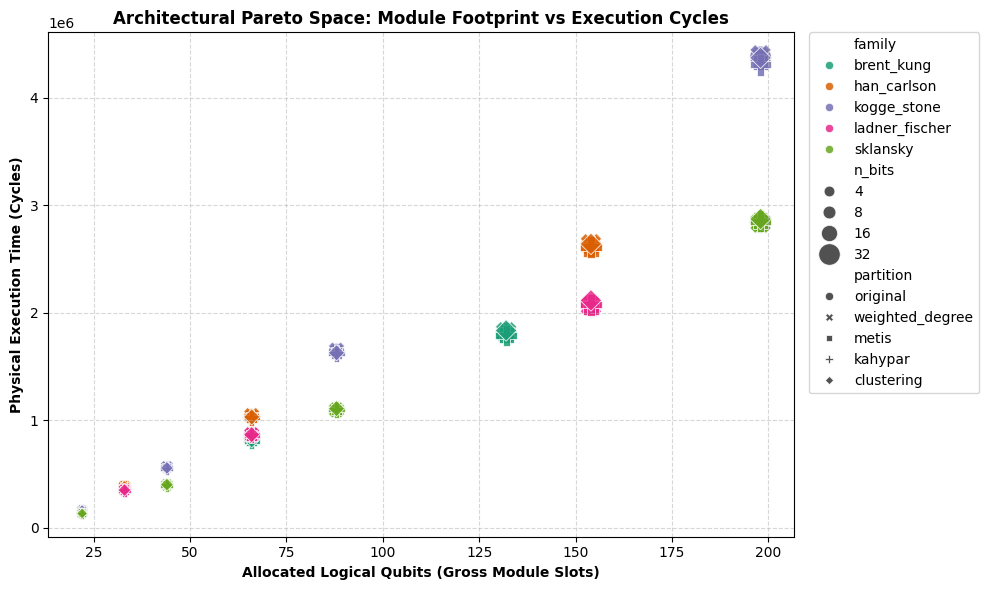

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_all,
    x="allocated_qubits",
    y="end_time",
    hue="family",
    style="partition",
    size="n_bits",
    sizes=(60, 240),
    alpha=0.85,
    palette="Dark2",
    ax=ax
)

ax.set_title("Architectural Pareto Space: Module Footprint vs Execution Cycles", fontsize=12, fontweight="bold")
ax.set_xlabel("Allocated Logical Qubits (Gross Module Slots)", fontweight="bold")
ax.set_ylabel("Physical Execution Time (Cycles)", fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.5)

# Place legend outside plot
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

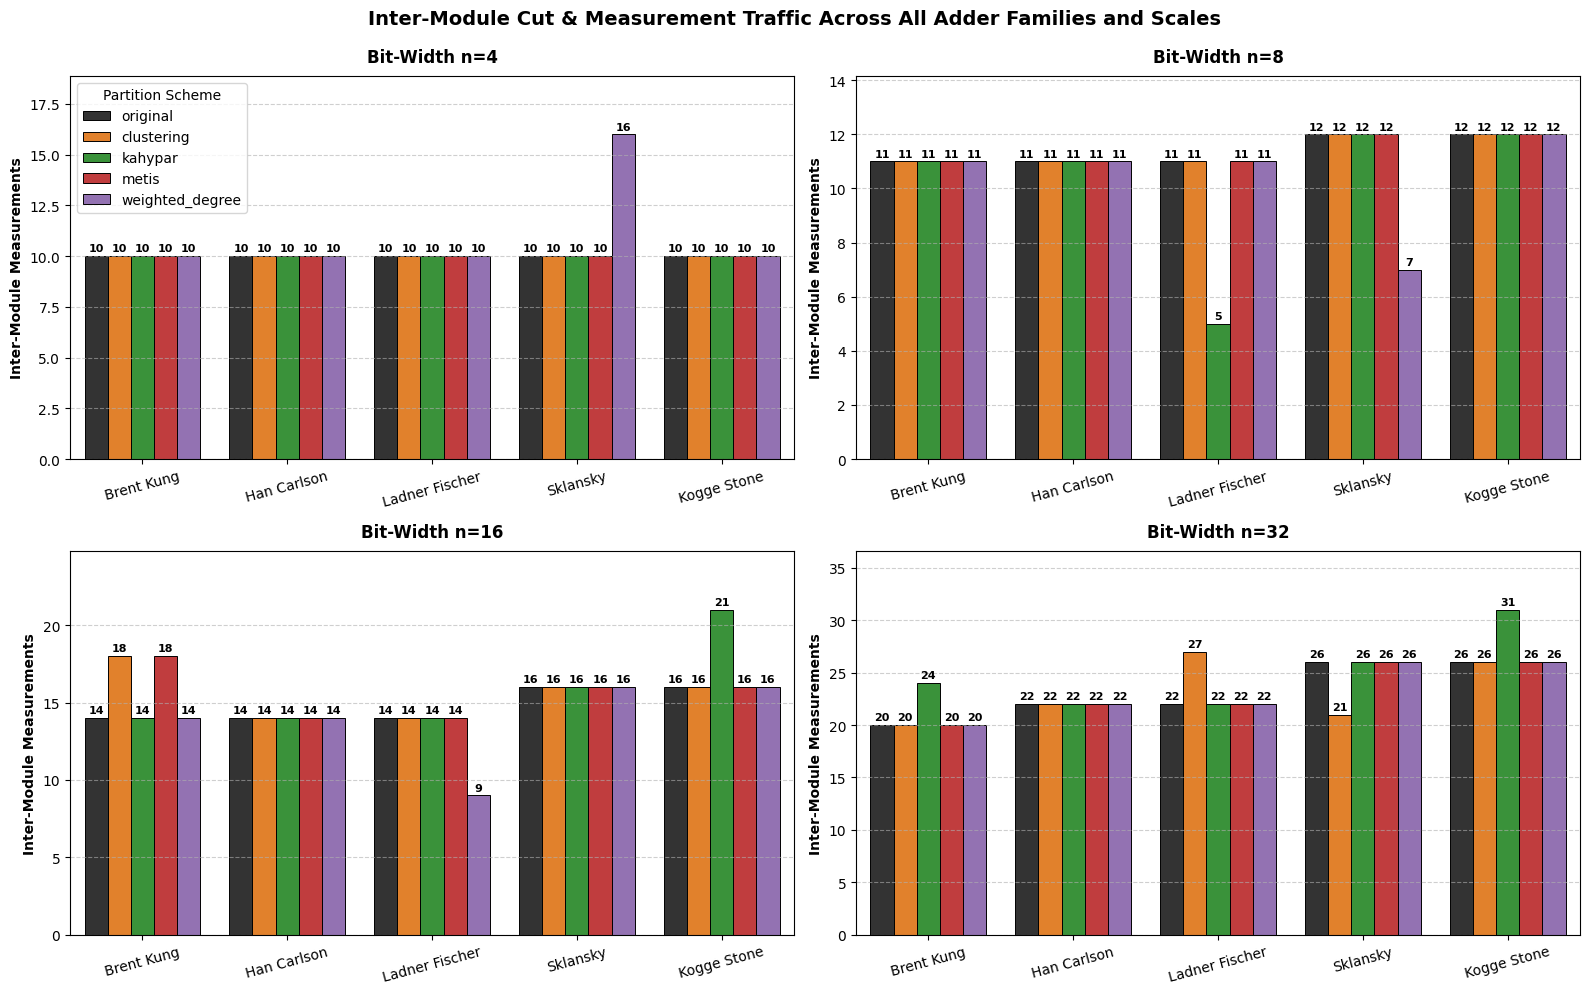

In [29]:
# Create a dynamic multi-panel grid comparing inter-module measurements across all bit-widths
n_vals = sorted(df_all["n_bits"].unique())
ncols = 2 if len(n_vals) > 1 else 1
nrows = int(np.ceil(len(n_vals) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharey=False)
axes = np.array(axes).flatten()

# 1. Dynamically order partitions: anchor 'original' first, then sort remaining
all_partitions = list(df_all["partition"].unique())
if "original" in all_partitions:
    all_partitions.remove("original")
    partition_order = ["original"] + sorted(all_partitions)
else:
    partition_order = sorted(all_partitions)

# Assign distinct colors while reserving dark charcoal for the baseline
palette_colors = sns.color_palette("tab10", len(partition_order))
color_map = dict(zip(partition_order, palette_colors))
if "original" in color_map:
    color_map["original"] = "#333333"

# 2. Format adder family names for clean x-axis labels
family_order = ["brent_kung", "han_carlson", "ladner_fischer", "sklansky", "kogge_stone"]
clean_labels = [f.replace("_", " ").title() for f in family_order]
family_map = dict(zip(family_order, clean_labels))

# 3. Plot each bit-width in its own subplot panel
for idx, n in enumerate(n_vals):
    ax = axes[idx]
    sub_df = df_all[df_all["n_bits"] == n].copy()
    sub_df["clean_family"] = sub_df["family"].map(family_map)

    sns.barplot(
        data=sub_df,
        x="clean_family",
        y="measurements",
        hue="partition",
        order=[family_map[f] for f in family_order if f in sub_df["family"].unique()],
        hue_order=partition_order,
        palette=color_map,
        edgecolor="black",
        linewidth=0.7,
        ax=ax,
    )

    # Annotate integer measurement counts on top of bars
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(
                f"{int(h)}",
                (p.get_x() + p.get_width() / 2.0, h),
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
                xytext=(0, 2),
                textcoords="offset points",
            )

    ax.set_title(f"Bit-Width n={n}", fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel("Inter-Module Measurements", fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Leave headroom for labels
    max_val = sub_df["measurements"].max()
    ax.set_ylim(0, max_val * 1.18 if max_val > 0 else 10)

    # Maintain a single unified legend on the first subplot
    if idx == 0:
        ax.legend(title="Partition Scheme", loc="upper left")
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

# 4. Hide unused subplot axes if total bit-widths is odd
for j in range(len(n_vals), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Inter-Module Cut & Measurement Traffic Across All Adder Families and Scales",
    fontsize=14,
    fontweight="bold",
    y=0.99,
)
plt.tight_layout()
plt.show()

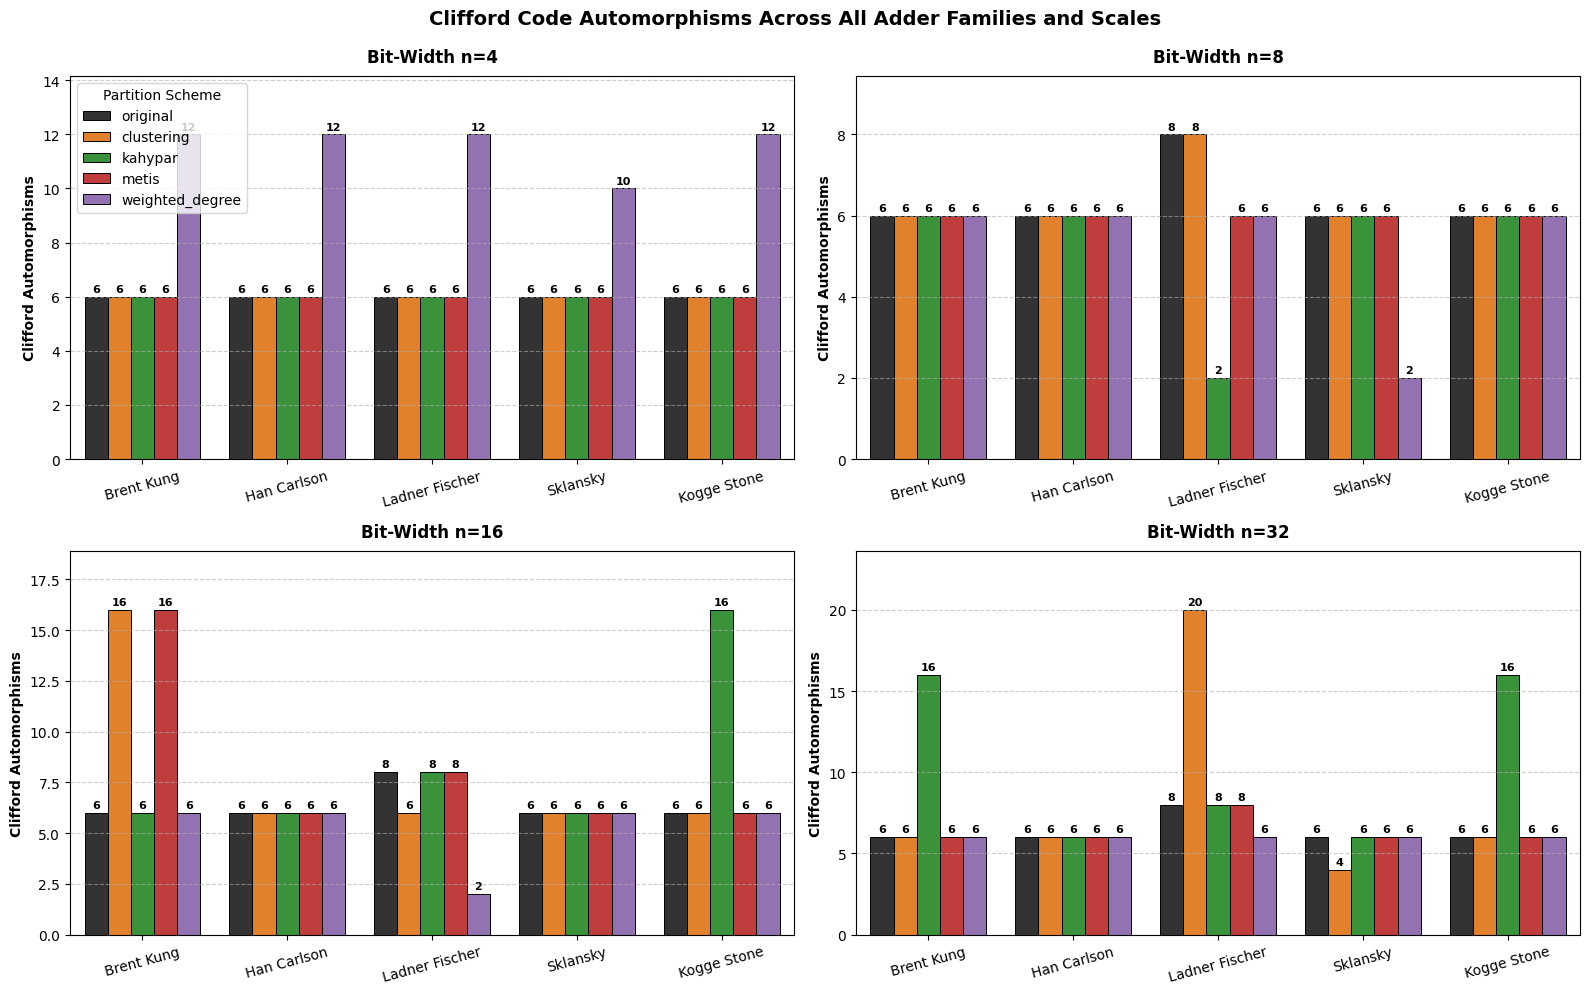

In [30]:
# Create a dynamic multi-panel grid comparing Clifford automorphisms across all bit-widths
n_vals = sorted(df_all["n_bits"].unique())
ncols = 2 if len(n_vals) > 1 else 1
nrows = int(np.ceil(len(n_vals) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharey=False)
axes = np.array(axes).flatten()

# 1. Dynamically order partitions: anchor 'original' first, then sort remaining
all_partitions = list(df_all["partition"].unique())
if "original" in all_partitions:
    all_partitions.remove("original")
    partition_order = ["original"] + sorted(all_partitions)
else:
    partition_order = sorted(all_partitions)

# Assign distinct colors while reserving dark charcoal for the baseline
palette_colors = sns.color_palette("tab10", len(partition_order))
color_map = dict(zip(partition_order, palette_colors))
if "original" in color_map:
    color_map["original"] = "#333333"

# 2. Format adder family names for clean x-axis labels
family_order = ["brent_kung", "han_carlson", "ladner_fischer", "sklansky", "kogge_stone"]
clean_labels = [f.replace("_", " ").title() for f in family_order]
family_map = dict(zip(family_order, clean_labels))

# 3. Plot each bit-width in its own subplot panel
for idx, n in enumerate(n_vals):
    ax = axes[idx]
    sub_df = df_all[df_all["n_bits"] == n].copy()
    sub_df["clean_family"] = sub_df["family"].map(family_map)

    sns.barplot(
        data=sub_df,
        x="clean_family",
        y="automorphisms",
        hue="partition",
        order=[family_map[f] for f in family_order if f in sub_df["family"].unique()],
        hue_order=partition_order,
        palette=color_map,
        edgecolor="black",
        linewidth=0.7,
        ax=ax,
    )

    # Annotate integer automorphism counts on top of bars
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(
                f"{int(h)}",
                (p.get_x() + p.get_width() / 2.0, h),
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
                xytext=(0, 2),
                textcoords="offset points",
            )

    ax.set_title(f"Bit-Width n={n}", fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel("Clifford Automorphisms", fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Leave headroom for labels
    max_val = sub_df["automorphisms"].max()
    ax.set_ylim(0, max_val * 1.18 if max_val > 0 else 10)

    # Maintain a single unified legend on the first subplot
    if idx == 0:
        ax.legend(title="Partition Scheme", loc="upper left")
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

# 4. Hide unused subplot axes if total bit-widths count is odd
for j in range(len(n_vals), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Clifford Code Automorphisms Across All Adder Families and Scales",
    fontsize=14,
    fontweight="bold",
    y=0.99,
)
plt.tight_layout()
plt.show()

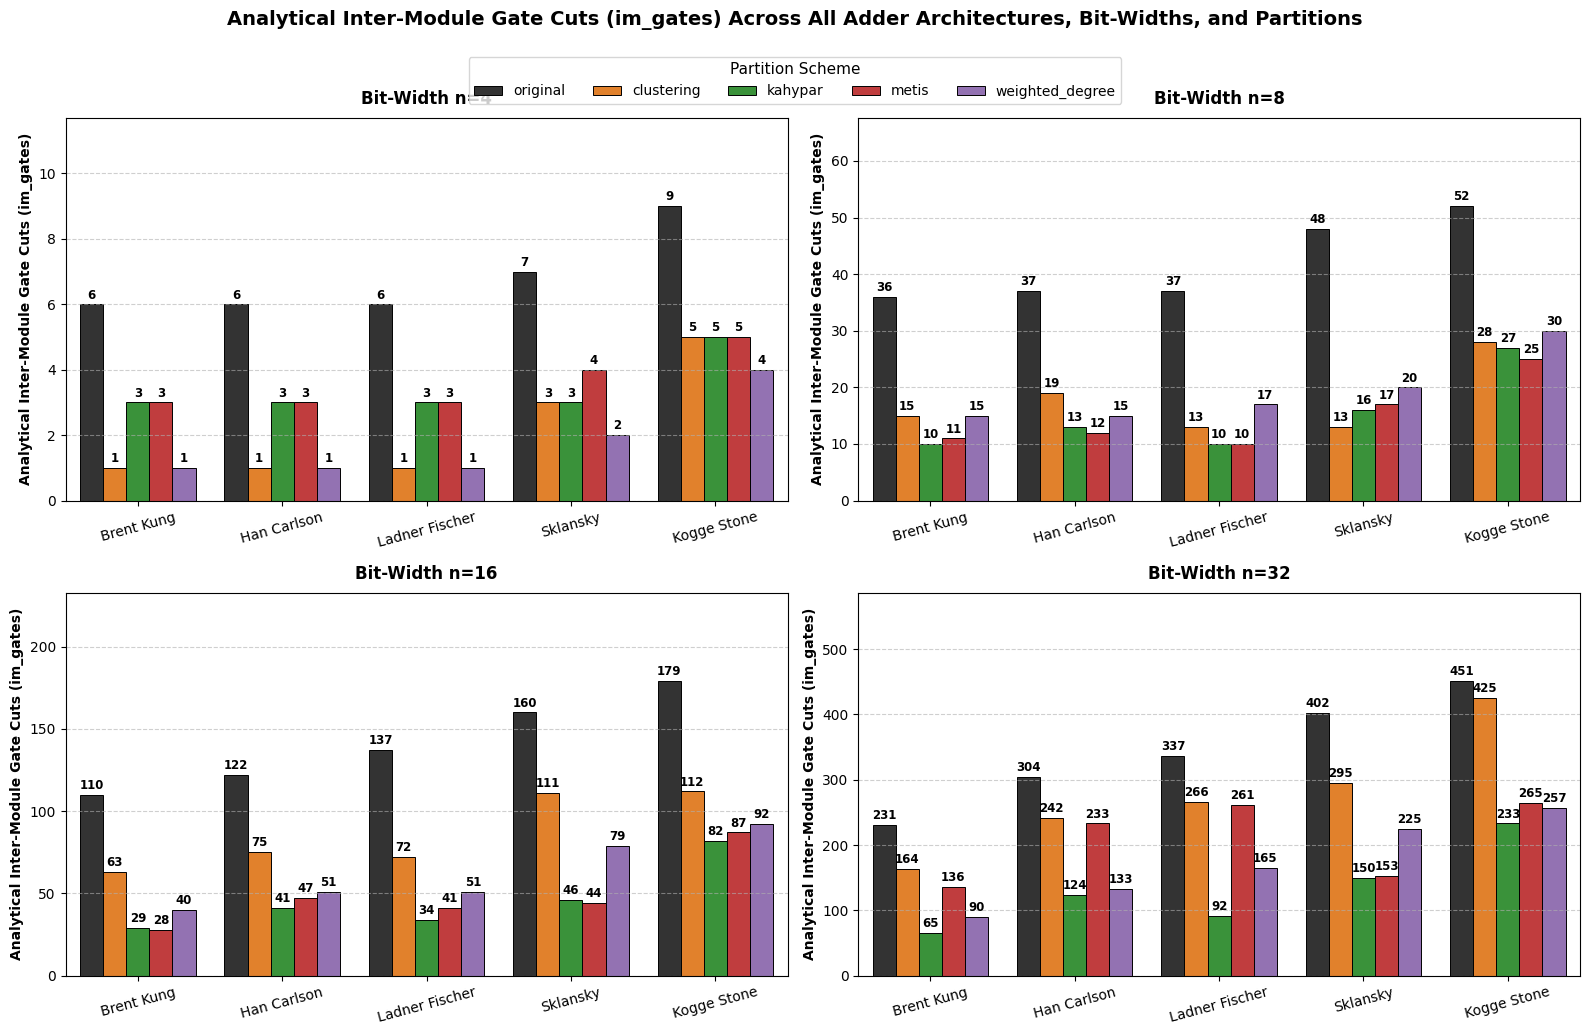

In [31]:
# Cell: Compare Inter-Module Cut Measurements Across All Adders, Bit-Widths, and Partitions

# 1. Configuration & Metric Selection
TARGET_METRIC = "im_gates"  # Switch to 'im_gates' if comparing analytical 2-qubit cuts
METRIC_LABEL = "Inter-Module Measurements (Cut Syndromes)" if TARGET_METRIC == "measurements" else "Analytical Inter-Module Gate Cuts (im_gates)"

# 2. Dynamic Layout Calculation
n_vals = sorted(df_all["n_bits"].unique())
ncols = 2 if len(n_vals) > 1 else 1
nrows = int(np.ceil(len(n_vals) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharey=False)
axes = np.array(axes).flatten()

# 3. Dynamic Partition Ordering & Palette Mapping
all_partitions = list(df_all["partition"].unique())
if "original" in all_partitions:
    all_partitions.remove("original")
    partition_order = ["original"] + sorted(all_partitions)
else:
    partition_order = sorted(all_partitions)

color_palette = dict(zip(partition_order, sns.color_palette("tab10", len(partition_order))))
if "original" in color_palette:
    color_palette["original"] = "#333333"

# Standardized parallel prefix adder ordering
family_order = ["brent_kung", "han_carlson", "ladner_fischer", "sklansky", "kogge_stone"]
clean_order = [f.replace("_", " ").title() for f in family_order]
present_adders = [a for a in clean_order if a in df_all["clean_adder"].unique()]

# 4. Render Subplot for Each Bit-Width
for idx, n in enumerate(n_vals):
    ax = axes[idx]
    sub_df = df_all[df_all["n_bits"] == n].copy()

    sns.barplot(
        data=sub_df,
        x="clean_adder",
        y=TARGET_METRIC,
        hue="partition",
        order=present_adders,
        hue_order=partition_order,
        palette=color_palette,
        edgecolor="black",
        linewidth=0.7,
        ax=ax,
    )

    # Annotate integer values directly on top of bars
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(
                f"{int(h)}",
                (p.get_x() + p.get_width() / 2.0, h),
                ha="center",
                va="bottom",
                fontsize=8.5,
                fontweight="bold",
                xytext=(0, 2),
                textcoords="offset points",
            )

    ax.set_title(f"Bit-Width n={n}", fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel(METRIC_LABEL, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Apply 30% headroom to prevent annotations colliding with borders
    max_val = sub_df[TARGET_METRIC].max() if not sub_df.empty else 10
    ax.set_ylim(0, max_val * 1.30 if max_val > 0 else 10)

    # Strip subplot legends to route into a single unified figure legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Remove unused axes if bit-width count is odd
for j in range(len(n_vals), len(axes)):
    fig.delaxes(axes[j])

# 5. Global Shared Legend and Titles
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Partition Scheme",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=min(len(partition_order), 5),
    frameon=True,
    fontsize=10,
    title_fontsize=11,
)

fig.suptitle(
    f"{METRIC_LABEL} Across All Adder Architectures, Bit-Widths, and Partitions",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()

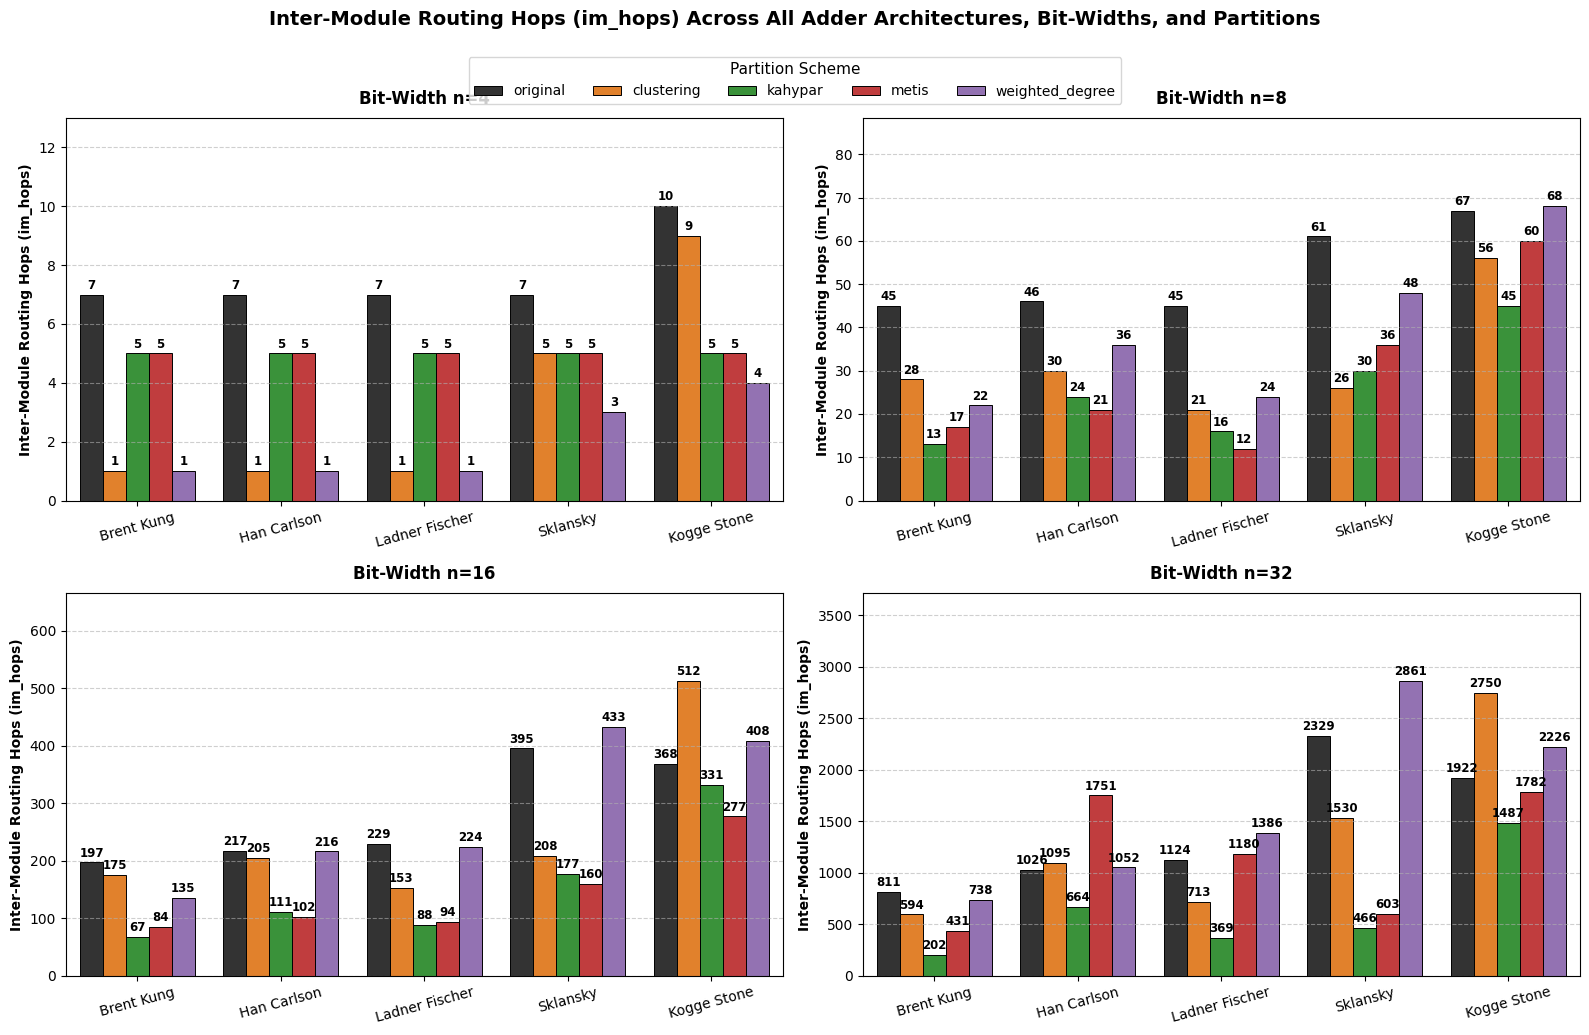

In [33]:
# Cell: Compare Inter-Module Routing Hops (im_hops) Across All Adders, Bit-Widths, and Partitions

TARGET_METRIC = "im_hops"
METRIC_LABEL = "Inter-Module Routing Hops (im_hops)"

if TARGET_METRIC not in df_all.columns:
    raise KeyError(f"Column '{TARGET_METRIC}' not found in df_all. Verify run_benchmarks.py logs this metric.")

# 1. Dynamic Grid Layout
n_vals = sorted(df_all["n_bits"].unique())
ncols = 2 if len(n_vals) > 1 else 1
nrows = int(np.ceil(len(n_vals) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharey=False)
axes = np.array(axes).flatten()

# 2. Dynamic Partition Ordering & Palette Mapping
all_partitions = list(df_all["partition"].unique())
if "original" in all_partitions:
    all_partitions.remove("original")
    partition_order = ["original"] + sorted(all_partitions)
else:
    partition_order = sorted(all_partitions)

color_palette = dict(zip(partition_order, sns.color_palette("tab10", len(partition_order))))
if "original" in color_palette:
    color_palette["original"] = "#333333"

# Standardized parallel prefix adder ordering
family_order = ["brent_kung", "han_carlson", "ladner_fischer", "sklansky", "kogge_stone"]
clean_order = [f.replace("_", " ").title() for f in family_order]
present_adders = [a for a in clean_order if a in df_all["clean_adder"].unique()]

# 3. Render Subplot for Each Bit-Width
for idx, n in enumerate(n_vals):
    ax = axes[idx]
    sub_df = df_all[df_all["n_bits"] == n].copy()

    sns.barplot(
        data=sub_df,
        x="clean_adder",
        y=TARGET_METRIC,
        hue="partition",
        order=present_adders,
        hue_order=partition_order,
        palette=color_palette,
        edgecolor="black",
        linewidth=0.7,
        ax=ax,
    )

    # Annotate integer values directly on top of bars
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(
                f"{int(h)}",
                (p.get_x() + p.get_width() / 2.0, h),
                ha="center",
                va="bottom",
                fontsize=8.5,
                fontweight="bold",
                xytext=(0, 2),
                textcoords="offset points",
            )

    ax.set_title(f"Bit-Width n={n}", fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel(METRIC_LABEL, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    max_val = sub_df[TARGET_METRIC].max() if not sub_df.empty else 10
    ax.set_ylim(0, max_val * 1.30 if max_val > 0 else 10)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Remove unused axes if bit-width count is odd
for j in range(len(n_vals), len(axes)):
    fig.delaxes(axes[j])

# 4. Global Shared Legend and Titles
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Partition Scheme",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=min(len(partition_order), 5),
    frameon=True,
    fontsize=10,
    title_fontsize=11,
)

fig.suptitle(
    f"{METRIC_LABEL} Across All Adder Architectures, Bit-Widths, and Partitions",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()

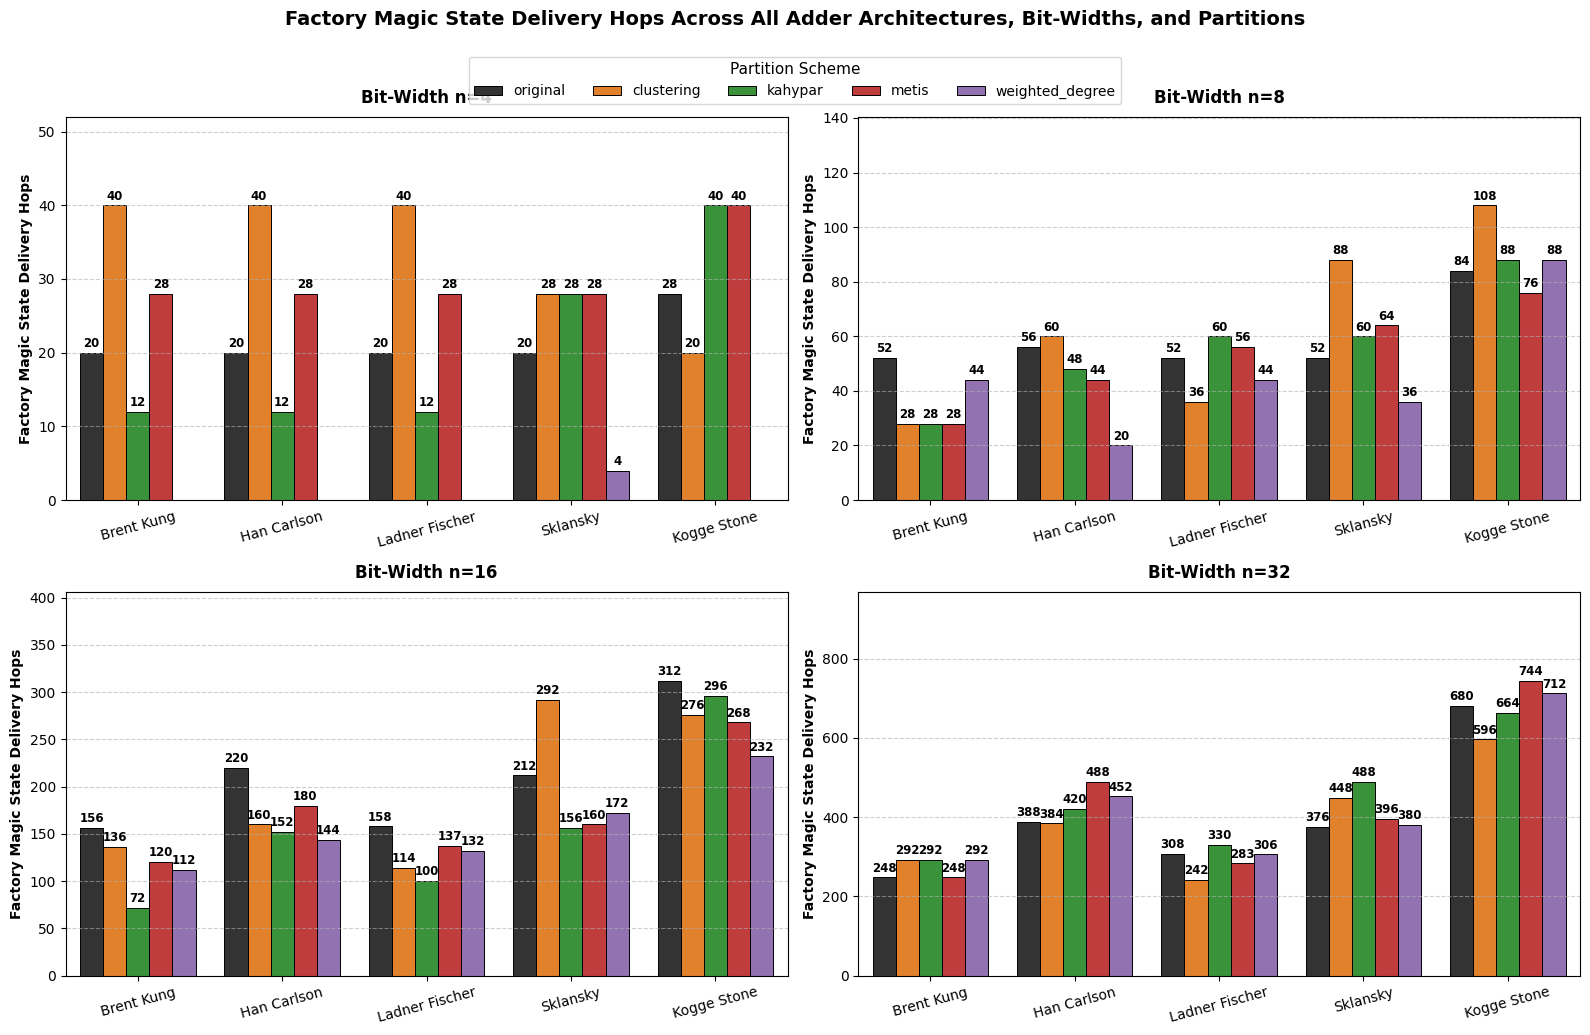

In [34]:
# Cell: Compare Magic State Factory Delivery Hops Across All Adders, Bit-Widths, and Partitions

# Auto-detect logged column naming convention
if "factory_im_hops" in df_all.columns:
    TARGET_METRIC = "factory_im_hops"
elif "factory_delivery_hops" in df_all.columns:
    TARGET_METRIC = "factory_delivery_hops"
else:
    raise KeyError("Neither 'factory_im_hops' nor 'factory_delivery_hops' found in df_all.")

METRIC_LABEL = "Factory Magic State Delivery Hops"

# 1. Dynamic Grid Layout
n_vals = sorted(df_all["n_bits"].unique())
ncols = 2 if len(n_vals) > 1 else 1
nrows = int(np.ceil(len(n_vals) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharey=False)
axes = np.array(axes).flatten()

# 2. Dynamic Partition Ordering & Palette Mapping
all_partitions = list(df_all["partition"].unique())
if "original" in all_partitions:
    all_partitions.remove("original")
    partition_order = ["original"] + sorted(all_partitions)
else:
    partition_order = sorted(all_partitions)

color_palette = dict(zip(partition_order, sns.color_palette("tab10", len(partition_order))))
if "original" in color_palette:
    color_palette["original"] = "#333333"

# Standardized parallel prefix adder ordering
family_order = ["brent_kung", "han_carlson", "ladner_fischer", "sklansky", "kogge_stone"]
clean_order = [f.replace("_", " ").title() for f in family_order]
present_adders = [a for a in clean_order if a in df_all["clean_adder"].unique()]

# 3. Render Subplot for Each Bit-Width
for idx, n in enumerate(n_vals):
    ax = axes[idx]
    sub_df = df_all[df_all["n_bits"] == n].copy()

    sns.barplot(
        data=sub_df,
        x="clean_adder",
        y=TARGET_METRIC,
        hue="partition",
        order=present_adders,
        hue_order=partition_order,
        palette=color_palette,
        edgecolor="black",
        linewidth=0.7,
        ax=ax,
    )

    # Annotate integer values directly on top of bars
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(
                f"{int(h)}",
                (p.get_x() + p.get_width() / 2.0, h),
                ha="center",
                va="bottom",
                fontsize=8.5,
                fontweight="bold",
                xytext=(0, 2),
                textcoords="offset points",
            )

    ax.set_title(f"Bit-Width n={n}", fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel(METRIC_LABEL, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Scale headroom
    max_val = sub_df[TARGET_METRIC].max() if not sub_df.empty else 10
    ax.set_ylim(0, max_val * 1.30 if max_val > 0 else 10)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Remove unused axes if bit-width count is odd
for j in range(len(n_vals), len(axes)):
    fig.delaxes(axes[j])

# 4. Global Shared Legend and Titles
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Partition Scheme",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=min(len(partition_order), 5),
    frameon=True,
    fontsize=10,
    title_fontsize=11,
)

fig.suptitle(
    f"{METRIC_LABEL} Across All Adder Architectures, Bit-Widths, and Partitions",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()